In [1]:
import os
import re
import math
import shutil
import subprocess

from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.dates import DateFormatter
from dateutil.tz import tzutc, tzlocal
from scipy import stats
from scipy.optimize import brentq, curve_fit, fsolve, least_squares



import sys
import signal
import tempfile
import time
from collections import Counter
from IPython.display import clear_output

In [2]:
%load_ext autoreload
%autoreload 2

import official_GSSHA_Python_functions as gf

%load_ext autoreload
%autoreload 2

import official_GSSHA_Python_post_process_functions as gppf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
cwd = os.getcwd()
script_dir = Path.cwd() 

GSSHA_prj_name = "Waialua_FIM_testing"
model_dir = script_dir / GSSHA_prj_name
GSSHA_executables = script_dir / 'GSSHA_applications'
test_input_flow_results_dir = model_dir / "TEST_INPUT_FLOW_SIMULATIONS"

In [22]:
# Once Offset is determined, set up model paramters for running stage height maps
gage_readings = np.arange(26, 36.5, 0.5).tolist()
offset = 12 #13.835 USGS determined, 12.0 rating curve determined, 15.69 without correction

In [23]:
#Set up the storage of results
modeling_set_test_results= {"gauge_readings_ft":[],
                            "expected_WSE_m":[],
                            "expected_WSE_ft":[],  
                            "convergence_time": [], 
                            "input_flows":[]}

#Fill in some metadata about gauge readings, expected model outputs to figure out the rest
expected_model_outputs = [x - offset for x in gage_readings]
modeling_set_test_results["gauge_readings_ft"] = gage_readings
modeling_set_test_results["expected_WSE_ft"] = expected_model_outputs
expected_WSE_m = [round(ft * 0.3048, 2) for ft in expected_model_outputs]
modeling_set_test_results["expected_WSE_m"] = expected_WSE_m

# Calibrate for gauge datum offset

You will need to download peak water levels from the gauge's historical data. You can find this data on the USGS website of the gauge. Keep in mind, the record should only consist of the rating curve representative of the DEM. This DEM is from 2013, so the curve closest to 2013 is most representative. If the datum was changed before or after 2013, that data should be corrected.  You can use the stream stats tool to quickly view the gauge plot and the notes in the peak water level data to determine when the datum shifted. For waialua, the gauge datum was updated in 2005 (so everything 2006 and onwards is in the current datum).


link for waialua gauge peak water level data : https://waterdata.usgs.gov/monitoring-location/USGS-16210500/#dataTypeId=continuous-00065-0&period=P7D&showFieldMeasurements=true


link to stream stats for waialua gauge: https://streamstats.usgs.gov/ss/?gage=16210500&tab=plots

In [24]:
df_USGS_rating_curve = pd.read_csv("peaks-USGS-16210500.csv")


#only evaluate post 2006 data (gauge was installed in 2012) and only need discharge and stage
df_USGS_rating_curve = (
    df_USGS_rating_curve
    .sort_values("water_year")
    .set_index("water_year", drop=False)
)

df_USGS_rating_curve = df_USGS_rating_curve.loc[2006:]
df_USGS_discharge = df_USGS_rating_curve[
    df_USGS_rating_curve["parameter_code"] == 60
].copy()

df_USGS_stage = df_USGS_rating_curve[
    df_USGS_rating_curve["parameter_code"] == 65
].copy()

df_USGS_rating_curve = (
    df_USGS_discharge[["value"]]
    .rename(columns={"value": "discharge_cfs"})
    .merge(
        df_USGS_stage[["value"]]
        .rename(columns={"value": "stage_ft"}),
        left_index=True,
        right_index=True,
    )
    .reset_index()
)

df_USGS_rating_curve.head()

,water_year,discharge_cfs,stage_ft
0,2006,8530.0,27.64
1,2007,620.0,19.34
2,2008,2530.0,23.38
3,2009,11800.0,29.11
4,2010,1140.0,20.80


## Read OWS and OQC to match with rating curve

In [25]:
#---------------------------------------------------------------
####READ OWS FILE = WATER SURFACE ELEVATION AT GAUGE LOCATION######
#PATHS
ows_file_paths = gppf.get_flow_file_dict(
    test_input_flow_results_dir,
    ".ows"
)

#READING IT
ows_file_read = {}
for flow_cms, filepath in ows_file_paths.items():
    ows = gppf.read_GSSHA_ows(filepath.parent, filepath.name)

    ows_file_read[flow_cms] = ows

#DETERMINING PEAK WATER ELEVATION AT CONSTANT EQUILIBIRUM
peak_wse = {}
for flow_cms, df in ows_file_read.items():
    peak_wse[flow_cms] = df["WSE_m"].tail(120).mean()




#---------------------------------------------------------------
####READ OQC FILE = CUMULATIVE DISCHARGE AT GAUGE LOCATION######
#PATHS
oqc_file_paths = gppf.get_flow_file_dict(
    test_input_flow_results_dir,
    ".oqc"
)

#READING IT
oqc_file_read = {}
for flow_cms, filepath in oqc_file_paths.items():
    oqc = gppf.read_GSSHA_oqc(filepath)

    oqc_file_read[flow_cms] = oqc


#DETERMINING DISCHARGE AT STABLE EQUILIBIRUM CONDITIONS
oqc_stable_discharge = {} #max discharge recorded at gauge
for flow_cms, df in oqc_file_read.items():
    # Calculate instantaneous discharge
    df = gppf.cumulative_to_instantaneous(df)

    # Save the updated DataFrame back to the dictionary
    oqc_file_read[flow_cms] = df

    # Average of the last 60 minutes
    oqc_stable_discharge[flow_cms] = (
        df["instantaneous_discharge"].tail(120).median()
    )

####MERGE DATA INTO CLEAN ORGANIZED FORMAT FOR FURTHER PROCESSING
rating_curve_data = {
    flow_cms: {
        "discharge_cms": oqc_stable_discharge[flow_cms],
        "stage_m": peak_wse[flow_cms],
    }
    for flow_cms in peak_wse
}

In [26]:
#CREATE STAGE TO DISCHARGE RATING CURVE of model!
stage_model = gppf.fit_rating_curve(rating_curve_data)

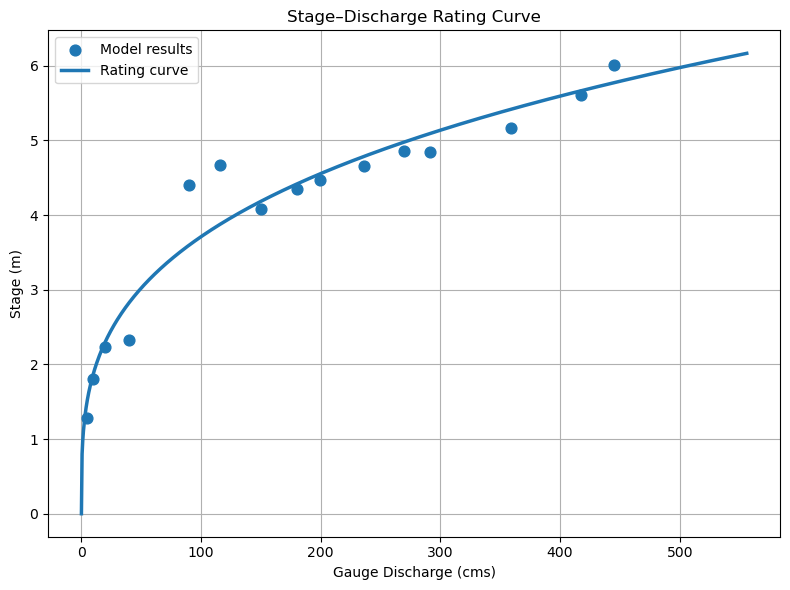

h = 0.949592 * Q^0.295985
R² = 0.93669


In [27]:

# Extract data
discharge = np.array(
    [rating_curve_data[flow]["discharge_cms"] for flow in sorted(rating_curve_data)],
    dtype=float,
)

stage = np.array(
    [rating_curve_data[flow]["stage_m"] for flow in sorted(rating_curve_data)],
    dtype=float,
)

# Smooth discharge values
discharge_smooth = np.linspace(
    0,
    discharge.max() * 1.25,
    1000,
)

# Predicted stage from fitted rating curve
stage_smooth = gppf.rating_curve_equation(
    discharge_smooth,
    stage_model["parameters"]["a"],
    stage_model["parameters"]["b"],
)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    discharge,
    stage,
    s=60,
    label="Model results",
    zorder=3,
)

plt.plot(
    discharge_smooth,
    stage_smooth,
    linewidth=2.5,
    label="Rating curve",
)

plt.xlabel("Gauge Discharge (cms)")
plt.ylabel("Stage (m)")
plt.title("Stage–Discharge Rating Curve")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(stage_model["equation"])
print(f'R² = {stage_model["r_squared"]:.5f}')

In [28]:
df_USGS_rating_curve["discharge_cms"] = (
    df_USGS_rating_curve["discharge_cfs"] * 0.028316846592
)

df_USGS_rating_curve["stage_m"] = (
    df_USGS_rating_curve["stage_ft"] * 0.3048
)

usgs_predicted_stage_m = gppf.rating_curve_equation(
    df_USGS_rating_curve["discharge_cms"].to_numpy(),
    stage_model["parameters"]["a"],
    stage_model["parameters"]["b"],
)

stage_offset_m = np.mean(
    df_USGS_rating_curve["stage_m"].to_numpy()
    - usgs_predicted_stage_m
)

print(f"Optimal vertical offset: {stage_offset_m:.4f} m")
print(f"Optimal vertical offset: {stage_offset_m / 0.3048:.4f} ft")

Optimal vertical offset: 3.6814 m
Optimal vertical offset: 12.0780 ft


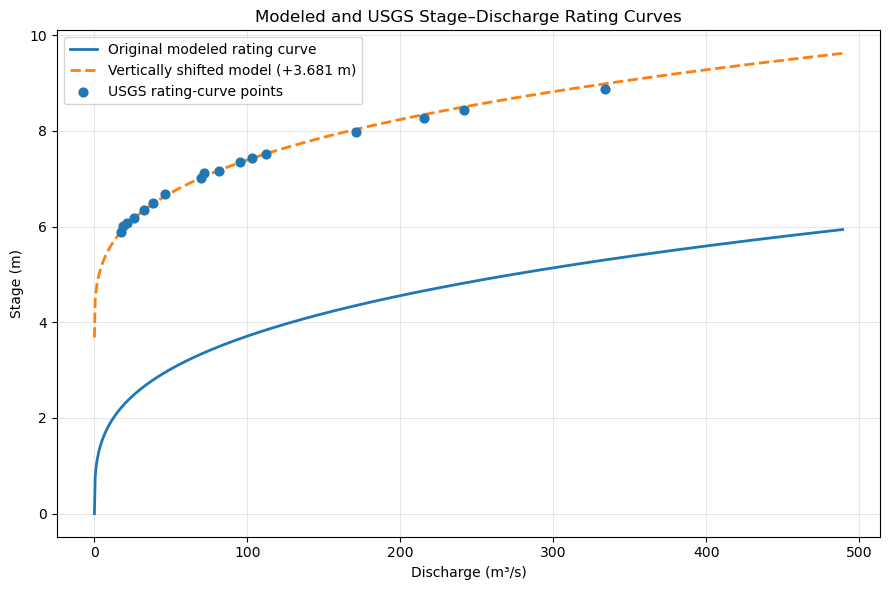

In [29]:
# Fitted rating-curve parameters
a = stage_model["parameters"]["a"]
b = stage_model["parameters"]["b"]

# USGS observations
Q_usgs = df_USGS_rating_curve["discharge_cms"].to_numpy()
stage_usgs = df_USGS_rating_curve["stage_m"].to_numpy()

# Smooth discharge values for plotting the modeled curves
Q_plot = np.linspace(
    0,
    max(
        Q_usgs.max(),
        stage_model["discharge"].max(),
    ) * 1.1,
    1000,
)

# Original modeled rating curve
stage_original = gppf.rating_curve_equation(
    Q_plot,
    a,
    b,
)

# Same modeled curve shifted vertically
stage_shifted = stage_original + stage_offset_m


plt.figure(figsize=(9, 6))

# Original model curve
plt.plot(
    Q_plot,
    stage_original,
    linewidth=2,
    label="Original modeled rating curve",
)

# Vertically shifted model curve
plt.plot(
    Q_plot,
    stage_shifted,
    linewidth=2,
    linestyle="--",
    label=f"Vertically shifted model ({stage_offset_m:+.3f} m)",
)

# Original USGS stage-discharge points
plt.scatter(
    Q_usgs,
    stage_usgs,
    s=40,
    label="USGS rating-curve points",
    zorder=3,
)

plt.xlabel("Discharge (m³/s)")
plt.ylabel("Stage (m)")
plt.title("Modeled and USGS Stage–Discharge Rating Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Set up datum offset and continue for results

# First determine input flows needed for modeling water surface elevations


## Read ows file and record peak WSE at model convergence

In [30]:
ows_file_paths = gppf.get_flow_file_dict(
    test_input_flow_results_dir,
    ".ows"
)
ows_file_read = {}
for flow_cms, filepath in ows_file_paths.items():
    ows = gppf.read_GSSHA_ows(filepath.parent, filepath.name)

    ows_file_read[flow_cms] = ows



peak_wse = {}
for flow_cms, df in ows_file_read.items():
    peak_wse[flow_cms] = df["WSE_m"].tail(120).mean()


In [31]:
wse_model = gppf.fit_robust_hybrid_curve(
    peak_wse,
    loss="soft_l1",
    f_scale=0.25,
)

## Plot water inflow vs water surface elevation to predict a curve

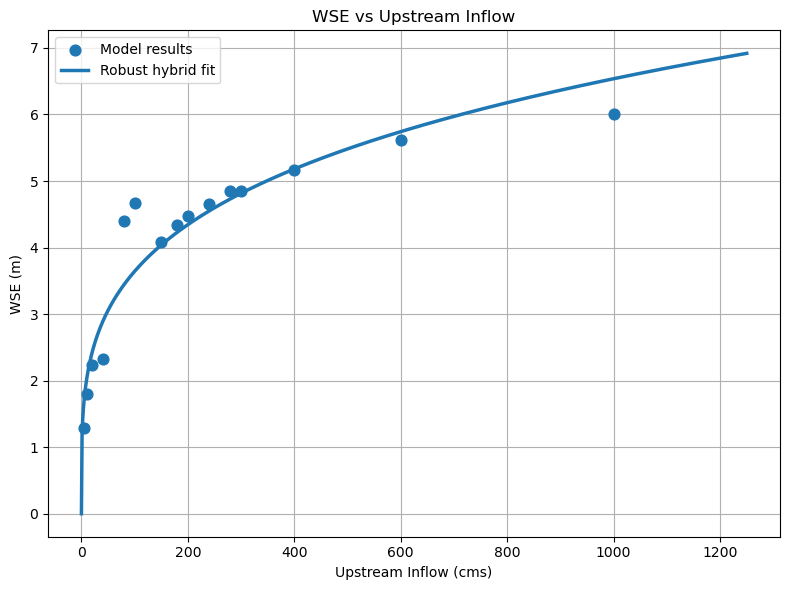

In [32]:
inflow = wse_model["x"]
wse = wse_model["y_observed"]

a = wse_model["parameters"]["a"]
b = wse_model["parameters"]["b"]
c = wse_model["parameters"]["c"]

inflow_smooth = np.linspace(
    0,
    inflow.max() * 1.25,
    1000,
)

wse_smooth = gppf.hybrid_fit(
    inflow_smooth,
    a,
    b,
    c,
)

plt.figure(figsize=(8, 6))

plt.scatter(
    inflow,
    wse,
    s=60,
    label="Model results",
    zorder=3,
)

plt.plot(
    inflow_smooth,
    wse_smooth,
    linewidth=2.5,
    label="Robust hybrid fit",
)

plt.xlabel("Upstream Inflow (cms)")
plt.ylabel("WSE (m)")
plt.title("WSE vs Upstream Inflow")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Add results to the model storage

In [33]:
#Determine input flows for each WSE determined in previous offset section
modeling_set_test_results["input_flows"] = [
    gppf.invert_hybrid_safe(
        wse,
        wse_model["parameters"]["a"],
        wse_model["parameters"]["b"],
        wse_model["parameters"]["c"],
    )
    for wse in modeling_set_test_results["expected_WSE_m"]
]


# Read the test flow .dep output to decide on a low flow boundary time and a high flow boundary time to ensure model reaches convergence

## Read dep files

In [34]:
dep_file_paths = gppf.get_flow_file_dict(
    test_input_flow_results_dir,
    ".dep"
)
dep_file_read ={}
for flow_cms, filepath in dep_file_paths.items():
    dep = gf.read_GSSHA_dep(filepath.parent, filepath.name)
    
    dep_file_read[flow_cms] = dep

dep_changes = {}
for flow_cms, dep_data in dep_file_read.items():
    dep_changes[flow_cms] = gf.calculate_dep_changes(
        dep_data,
        cell_size=10,
        depth_threshold=0.01
    )

## Determie Timestep of equilibrium (less than 1000m2 of area change at each timestep for 3 hours long)

In [35]:
equilibrium_timesteps = {
    flow_cms: gppf.find_equilibrium_timestep(df)
    for flow_cms, df in dep_changes.items()
}

print(equilibrium_timesteps)

{5: 390.5, 10: 390.5, 20: 360.5, 40: 720.5, 80: 750.5, 100: 660.5, 150: 690.5, 180: 810.5, 200: 840.5, 240: 480.5, 280: 540.5, 300: 450.5, 400: 390.5, 600: 390.5, 1000: 300.5}


## Plot timestep convergence

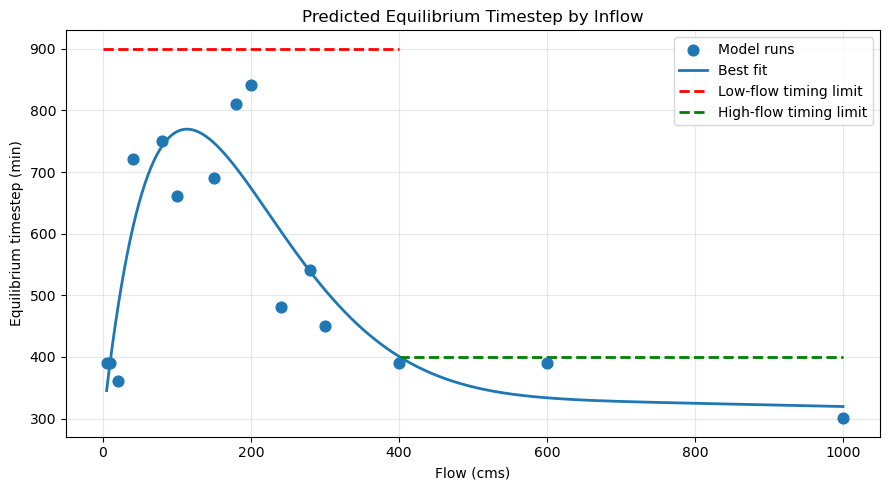

In [36]:

# Convert equilibrium_timesteps dictionary to arrays
flow = np.array(
    sorted(equilibrium_timesteps.keys()),
    dtype=float,
)

time = np.array(
    [equilibrium_timesteps[f] for f in flow],
    dtype=float,
)


# Remove missing values
valid = np.isfinite(flow) & np.isfinite(time)

flow_fit = flow[valid]
time_fit = time[valid]

# Scale flow between 0 and 1
flow_min = flow_fit.min()
flow_max = flow_fit.max()
def top_right_curve(flow_values, c0, c1, amplitude, p, q):
    """
    Asymmetric top-right curve.

    Constraints used during fitting:
        0 < p < 1
        q > 1
    """

    u = (
        (np.asarray(flow_values, dtype=float) - flow_min)
        / (flow_max - flow_min)
    )

    # Keep values valid at the endpoints
    u = np.clip(u, 0.0, 1.0)

    baseline = c0 + c1 * u
    curved_part = amplitude * (u ** p) * ((1.0 - u) ** q)

    return baseline + curved_part


def residuals(parameters):
    return (
        top_right_curve(flow_fit, *parameters)
        - time_fit
    )



initial_guess = [
    time_fit[0],
    time_fit[-1] - time_fit[0],
    2000.0,
    0.5,
    2.0,
]


fit_result = least_squares(
    residuals,
    x0=initial_guess,
    bounds=(
        [
            0.0,
            -2000.0,
            0.0,
            0.001,
            1.001,
        ],
        [
            2000.0,
            2000.0,
            10000.0,
            0.999,
            20.0,
        ],
    ),
)

c0, c1, amplitude, p, q = fit_result.x


# Smooth fitted curve
flow_plot = np.linspace(
    flow_min,
    flow_max,
    1000,
)

time_predicted = top_right_curve(
    flow_plot,
    c0,
    c1,
    amplitude,
    p,
    q,
)


plt.figure(figsize=(9, 5))

plt.scatter(
    flow_fit,
    time_fit,
    s=60,
    zorder=3,
    label="Model runs",
)

plt.plot(
    flow_plot,
    time_predicted,
    linewidth=2,
    label="Best fit",
)

# Horizontal maximum line from 0 to 400 cms
plt.hlines(
    y=900,
    xmin=0,
    xmax=400,
    colors="red",
    linestyles="--",
    linewidth=2,
    label="Low-flow timing limit",
)

# Horizontal minimum line starting at 400 cms
plt.hlines(
    y=400,
    xmin=400,
    xmax=flow_max,
    colors="green",
    linestyles="--",
    linewidth=2,
    label="High-flow timing limit",
)

plt.xlabel("Flow (cms)")
plt.ylabel("Equilibrium timestep (min)")
plt.title("Predicted Equilibrium Timestep by Inflow")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Define model simulation time and incorporate to model storage

In [37]:
low_flow_threshold = 450
low_flow_timing = 900
high_flow_timing = 400

In [38]:
input_flows = modeling_set_test_results["input_flows"]


equilibrium_times = [
    low_flow_timing if flow < low_flow_threshold else high_flow_timing
    for flow in input_flows
]
modeling_set_test_results['convergence_time'] = equilibrium_times

# Save model test results to use in final model simulation

In [40]:
df = pd.DataFrame(modeling_set_test_results)
df.to_csv(test_input_flow_results_dir / "modeling_test_results.csv", index=False)

print(f"Saved to:\n{test_input_flow_results_dir / "modeling_test_results.csv"}")

Saved to:
C:\Users\bgorberg\Documents\GitHub\Flood_Stage_Maps\RUN_GSSHA\Waialua_FIM_testing\TEST_INPUT_FLOW_SIMULATIONS\modeling_test_results.csv
